In [1]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import numpy as np

#load
df = pd.read_csv('../data/cleaned/WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [2]:
# feature engineering
df["TenureGroup"] = pd.cut(
    df["YearsAtCompany"],
    bins=[0, 2, 5, 10, 40],
    labels=["Early", "Mid", "Senior", "Long"],
    include_lowest = True
)

df["IncomeLevel"] = pd.qcut(
    df["MonthlyIncome"],
    3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df["WorkStress"] = df["OverTime"] * (4 - df["WorkLifeBalance"])

df["YearsSinceLastPromotion_ratio"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)

df["SatisfactionIndex"] = (
    df["JobSatisfaction"] +
    df["EnvironmentSatisfaction"] +
    df["RelationshipSatisfaction"]
) / 3

df = pd.get_dummies(df, columns=["TenureGroup", "IncomeLevel"], drop_first=True)

In [3]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

attrition_corr = correlation_matrix["Attrition"].drop("Attrition").sort_values(ascending=False)

print("\nTop features positively correlated with Attrition:")
print(attrition_corr.head(10))


Top features positively correlated with Attrition:
OverTime                         0.246118
WorkStress                       0.222956
DistanceFromHome                 0.077924
NumCompaniesWorked               0.043494
Gender                           0.029453
MonthlyRate                      0.015170
YearsSinceLastPromotion_ratio    0.010412
PerformanceRating                0.002889
HourlyRate                      -0.006846
PercentSalaryHike               -0.013478
Name: Attrition, dtype: float64


In [4]:
import joblib
import shap
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# split
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# correlation filter

corr = X_train.join(y_train).corr(numeric_only=True)["Attrition"].drop("Attrition")
keep_corr = corr[abs(corr) >= 0.03].index.tolist()

X_train_c = X_train[keep_corr]
X_test_c  = X_test[keep_corr]


model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_c, y_train)

# feature important
imp = pd.Series(model.feature_importances_, index=X_train_c.columns)
top_cols = imp.sort_values(ascending=False).head(20).index.tolist()
joblib.dump(top_cols, "../backend/model/top_cols.pkl")


['../backend/model/top_cols.pkl']

=== MODEL PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       247
           1       0.39      0.51      0.44        47

    accuracy                           0.80       294
   macro avg       0.65      0.68      0.66       294
weighted avg       0.82      0.80      0.81       294

ROC-AUC: 0.7900766646567318


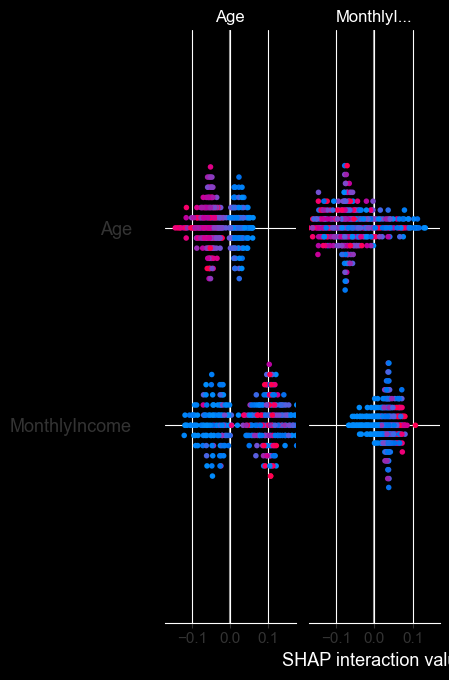

In [5]:

X_train_f = X_train_c[top_cols]
X_test_f  = X_test_c[top_cols]

# retrain
model.fit(X_train_f, y_train)


y_prob = model.predict_proba(X_test_f)[:, 1]

threshold = 0.35
y_pred = (y_prob >= threshold).astype(int)

print("=== MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_f)

shap.summary_plot(shap_values, X_test_f)

In [6]:
X_train.to_csv("../data/final/X_train.csv", index=False)
X_test.to_csv("../data/final/X_test.csv", index=False)

y_train.to_csv("../data/final/y_train.csv", index=False)
y_test.to_csv("../data/final/y_test.csv", index=False)

In [7]:
train_df = X_train_f.copy()
train_df["Attrition"] = y_train.values

test_df = X_test_f.copy()
test_df["Attrition"] = y_test.values

train_df.to_csv("../data/final/train_data.csv", index=False)
test_df.to_csv("../data/final/test_data.csv", index=False)

In [8]:
final_ml_dataset = pd.concat([train_df, test_df], axis=0)

final_ml_dataset.to_csv(
    "../data/final/final_ml_dataset.csv",
    index=False
)

In [9]:
df = final_ml_dataset
column_info = pd.DataFrame({
    "Column": df.columns,
    "DataType": df.dtypes.values
})

print(column_info)

                      Column DataType
0              MonthlyIncome    int64
1                        Age    int64
2          TotalWorkingYears    int64
3                  DailyRate    int64
4             YearsAtCompany    int64
5       YearsWithCurrManager    int64
6          SatisfactionIndex  float64
7                   OverTime    int64
8           DistanceFromHome    int64
9           StockOptionLevel    int64
10        NumCompaniesWorked    int64
11                WorkStress    int64
12                  JobLevel    int64
13        YearsInCurrentRole    int64
14   EnvironmentSatisfaction    int64
15           JobSatisfaction    int64
16            JobInvolvement    int64
17     TrainingTimesLastYear    int64
18   YearsSinceLastPromotion    int64
19  RelationshipSatisfaction    int64
20                 Attrition    int64
